# Inputs:

## Data Input

In [11]:
from sklearn.exceptions import DataConversionWarning
import warnings

warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=RuntimeWarning)
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=DataConversionWarning)

In [12]:
import pandas as pd
import numpy as np

data = pd.read_csv("/Users/sonlamtong/Desktop/Python/Thesis/Technical Analysis /Data Set/aapl_Training_Data.csv")
data = data.set_index("Date")

training_data = data.loc[:, ~data.columns.isin(["target"])].copy()
target= data.loc[:, ["target"]].copy()

data.head()
display(training_data.shape, target.shape)

(3774, 91)

(3774, 1)

### Data Preparation:

In [13]:
def data_split(split_percentage, df):

    assert 0 < split_percentage < 1, "split_percentage must be a float between 0 and 1 (exclusive)"
    
    split_index = int(len(df) * split_percentage)

    train_df = df.iloc[:split_index].copy()
    test_df = df.iloc[split_index:].copy()
    
    return train_df, test_df

In [14]:
from sklearn.model_selection import train_test_split

def define_rule_based_indicators_list(X):
    rule_based_indicators =[]
    for col in X.columns:
        if len(X[col].unique()) <= 2:
            rule_based_indicators.append(col)
    
    return rule_based_indicators

print(define_rule_based_indicators_list(training_data))

#X, Valid_set, y, Valid_result = data_split(split_percentage=0.8, df=training_data.reset_index(drop=True))
X, Valid_set = data_split(split_percentage=0.8, df=training_data.reset_index(drop=True))
y, Valid_result = target.reset_index(drop=True).loc[X.index], target.reset_index(drop=True).loc[Valid_set.index]

['volatility_bbhi', 'volatility_bbli', 'volatility_kchi', 'volatility_kcli', 'trend_psar_up_indicator', 'trend_psar_down_indicator']


Text(0, 0.5, 'Price')

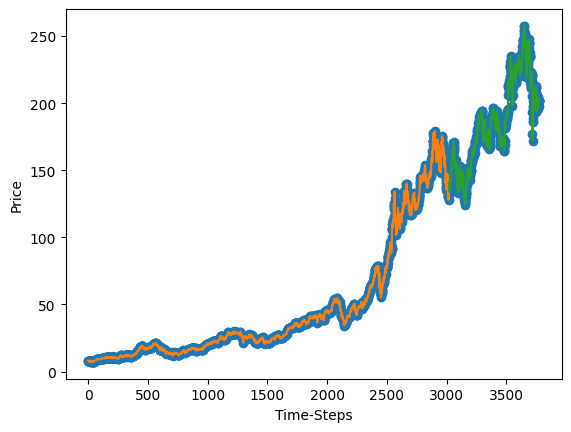

In [15]:
from matplotlib import pyplot as plt

df = training_data.reset_index(drop=True)
price = df.loc[:, 'close']
plt.plot(price.index, price.values, 'o')

for df in [X, Valid_set]:
    price = df.loc[:, 'close']
    plt.plot(price.index, price.values)
    
plt.xlabel("Time-Steps")
plt.ylabel("Price")

### Scoring for Tuning and Optimization:

In [16]:
#scoring = "accuracy"
scoring = "f1"

#### Fold CV fucntion:

In [17]:
def purged_kfold_split(X, n_splits=5, lookahead=5, embargo=0):
    fold_size = len(X) // n_splits
    for i in range(n_splits):
        test_start = i * fold_size
        test_end = (i + 1) * fold_size

        # Embargo
        embargo_start = test_end + 1
        embargo_end = embargo_start + embargo

        # Purge overlaps
        train_idx = list(range(0, test_start - lookahead)) + list(range(embargo_end, len(X)))
        test_idx = list(range(test_start, test_end))

        yield train_idx, test_idx

#### Model Evaluation:

In [18]:
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import f1_score
from sklearn.model_selection import cross_val_score

# ---------------------------
# Feature Selection Ensemble function:
# ---------------------------

def Ensemble_Feature_Selection(X, selected_feature_set):
    
    X = X.loc[:, selected_feature_set]
    #X = scale_standard(X.copy())
    
    return X

# ---------------------------
# Evaluation functions:
# ---------------------------

def evaluation_score_test_with_threshold(base_model, X_train, y_train, X_test, y_test, best_threshold=False):

    calibrated_model = CalibratedClassifierCV(base_model, method='sigmoid', cv=5)
    calibrated_model.fit(X_train, y_train)
    
    if best_threshold == False:
        y_pred = calibrated_model.predict(X_test)
    else:
        y_proba = calibrated_model.predict_proba(X_test)[:, 1]  # Probabilities
        y_pred = (y_proba > best_threshold).astype(int)
    
    print(np.unique(y_pred, return_counts=True))

    return f1_score(y_true=y_test, y_pred=y_pred)

def dataframe_from_models_package(model, selected_feature_set, best_threshold=False):
    X_train_1 = X.copy()
    X_train_1 = Ensemble_Feature_Selection(X_train_1.copy(), selected_feature_set)
    y_train_1 = y.copy()

    X_test_1 = Valid_set.copy()
    X_test_1 = X_test_1.loc[:, X_train_1.columns.tolist()]
    y_test_1 = Valid_result.copy()

    f1_array = np.array([])
    for train_idx, test_idx in purged_kfold_split(X_train_1):
        X_train, X_test = X_train_1.iloc[train_idx], X_train_1.iloc[test_idx]
        y_train, y_test = y_train_1.iloc[train_idx], y_train_1.iloc[test_idx]
        
        f1 = evaluation_score_test_with_threshold(model, X_train, y_train, X_test, y_test, best_threshold)
        
        f1_array = np.append( f1_array, f1 )

    calibrated_model = CalibratedClassifierCV(model, method='sigmoid', cv=5)
    calibrated_model.fit(X=X_train_1, y=y_train_1)

    y_proba_1 = calibrated_model.predict_proba(X_test_1)[:, 1]
    y_pred_1 = (y_proba_1 > best_threshold).astype(int)

    print(np.unique(y_pred_1, return_counts=True))
    return f1_array.mean(), f1_score(y_true=y_test_1, y_pred=y_pred_1)

def evaluation_score_test(base_model, X_train_1, y_train_1):
    cv = purged_kfold_split(X_train_1.copy())
    scores = cross_val_score(estimator=base_model, X=X_train_1.copy(), y=y_train_1.copy(), cv=cv, scoring=scoring, n_jobs=-1)
    return np.mean(scores)

def evaluation_score_test_2(base_model, X_train_1, y_train_1):
    f1_array = np.array([])
    for train_idx, test_idx in purged_kfold_split(X_train_1.copy()):
        X_train, X_test = X_train_1.iloc[train_idx], X_train_1.iloc[test_idx]
        y_train, y_test = y_train_1.iloc[train_idx], y_train_1.iloc[test_idx]
        
        calibrated_model = CalibratedClassifierCV(base_model, method='sigmoid', cv=5)
        calibrated_model.fit(X_train, y_train)
        y_pred = calibrated_model.predict(X_test)
        #print(np.unique(y_pred, return_counts=True))

        f1_array = np.append( f1_array, f1_score(y_true=y_test, y_pred=y_pred) )
    return np.mean(f1_array)

## Models Input

In [19]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier

import joblib


paths_list = ['prediction dataset/xgb_model_with_threshold.pkl', 'prediction dataset/rf_model_with_threshold.pkl', 'prediction dataset/logr_model_with_threshold.pkl', 'prediction dataset/knn_model_with_threshold.pkl']
models_name = ["XGB", "Random Forest", "LogRegression", "KNNs"]
models = [joblib.load(model) for model in paths_list]

models_scores = {}

for model_package, name in zip(models, models_name):
    
    model = model_package['model']
    best_threshold = model_package['threshold']
    selected_feature_set = model_package['feature set']
    
    validation_score, test_score = dataframe_from_models_package(model, selected_feature_set, best_threshold)
    models_scores[name] = {
        "Vaid Score": validation_score, 
        "Test Score": test_score,
    }

(array([0, 1]), array([231, 372]))
(array([0, 1]), array([215, 388]))
(array([0, 1]), array([276, 327]))
(array([0, 1]), array([186, 417]))
(array([0, 1]), array([208, 395]))
(array([0, 1]), array([280, 475]))
(array([0, 1]), array([314, 289]))
(array([0, 1]), array([254, 349]))
(array([0, 1]), array([259, 344]))
(array([0, 1]), array([221, 382]))
(array([0, 1]), array([223, 380]))
(array([0, 1]), array([249, 506]))
(array([0, 1]), array([201, 402]))
(array([0, 1]), array([169, 434]))
(array([0, 1]), array([163, 440]))
(array([0, 1]), array([109, 494]))
(array([0, 1]), array([206, 397]))
(array([0, 1]), array([220, 535]))
(array([0, 1]), array([145, 458]))
(array([0, 1]), array([ 93, 510]))
(array([0, 1]), array([111, 492]))
(array([0, 1]), array([ 87, 516]))
(array([0, 1]), array([ 87, 516]))
(array([0, 1]), array([115, 640]))


In [20]:
valid_table = pd.DataFrame(models_scores).T

valid_table

,Vaid Score,Test Score
XGB,0.774223,0.771812
Random Forest,0.770197,0.765405
LogRegression,0.707872,0.765199
KNNs,0.721044,0.727101


# Weight Average Voting model:

In [21]:
'''
from sklearn.ensemble import VotingClassifier

# Normalize valid scores to use as weights
valid_scores = valid_table["Vaid Score"]

total = sum(valid_scores.values)

weights = []
estimators = []
for model_package, name in zip(models, models_name):
    weights.append( valid_scores[name]/total )
    estimators.append( (name, model_package['model']) )

#display(estimators)

ensemble = VotingClassifier(
    estimators=estimators,
    voting='soft',
    weights=weights
)

dataframe_from_models_package(ensemble, selected_feature_set=X.columns)
'''

'\nfrom sklearn.ensemble import VotingClassifier\n\n# Normalize valid scores to use as weights\nvalid_scores = valid_table["Vaid Score"]\n\ntotal = sum(valid_scores.values)\n\nweights = []\nestimators = []\nfor model_package, name in zip(models, models_name):\n    weights.append( valid_scores[name]/total )\n    estimators.append( (name, model_package[\'model\']) )\n\n#display(estimators)\n\nensemble = VotingClassifier(\n    estimators=estimators,\n    voting=\'soft\',\n    weights=weights\n)\n\ndataframe_from_models_package(ensemble, selected_feature_set=X.columns)\n'

In [31]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import f1_score

def optimize_disagreement_threshold(
    models,
    X_val,
    y_val,
    class_threshold=0.5,
    min_coverage=0.05,
    verbose=True,
    plot=True,
    debug_plot=True
):
    """
    Optimize the disagreement threshold (std of predicted probabilities) to maximize F1-score
    on confident predictions (i.e., samples where models mostly agree).

    Parameters:
    - models: list of trained classifiers that support predict_proba
    - X_val: validation feature set (pandas DataFrame or NumPy array)
    - y_val: validation labels (pandas Series or NumPy array)
    - class_threshold: probability threshold for binary classification (default: 0.5)
    - min_coverage: minimum % of samples to keep at each threshold (default: 0.05 = 5%)
    - verbose: print details for each threshold
    - plot: show F1-score vs. coverage
    - debug_plot: show histogram of disagreement values

    Returns:
    - best_threshold: disagreement std value with best F1-score
    - best_f1: best achieved F1-score
    - best_coverage: corresponding coverage
    """

    # 1. Collect prediction probabilities from all models
    all_probs = [model.predict_proba(X_val)[:, 1] for model in models]
    prob_matrix = np.vstack(all_probs).T

    # 2. Disagreement is the std deviation across model probabilities
    disagreement = np.std(prob_matrix, axis=1)

    thresholds = np.linspace(0.01, 0.2, 100)
    f1_scores = []
    coverages = []

    best_f1 = 0
    best_threshold = 0
    best_coverage = 0

    n_total = len(y_val)

    for t in thresholds:
        confident_idx = np.where(disagreement < t)[0]
        coverage = len(confident_idx) / n_total

        if coverage < min_coverage:
            f1_scores.append(0)
            coverages.append(coverage)
            continue

        confident_probs = prob_matrix[confident_idx]
        confident_y = y_val.iloc[confident_idx] if hasattr(y_val, "iloc") else y_val[confident_idx]
        avg_probs = confident_probs.mean(axis=1)
        preds = (avg_probs >= class_threshold).astype(int)

        f1 = f1_score(confident_y, preds)

        f1_scores.append(f1)
        coverages.append(coverage)

        if f1 > best_f1:
            best_f1 = f1
            best_threshold = t
            best_coverage = coverage

        if verbose:
            print(f"Threshold: {t:.3f} | F1: {f1:.4f} | Coverage: {coverage:.2%} | Samples: {len(confident_idx)}")
            try:
                label_array = np.array(confident_y).astype(int).flatten()
                label_dist = np.bincount(label_array)
                print(f"    Label distribution: {label_dist}")
            except Exception as e:
                print(f"    ⚠️  Could not compute label distribution: {e}")

    if verbose:
        print("\n✅ Best Disagreement Threshold Results:")
        print(f"🔹 Threshold: {best_threshold:.3f}")
        print(f"🔹 F1-score: {best_f1:.4f}")
        print(f"🔹 Coverage: {best_coverage:.2%}")

    if plot:
        plt.figure(figsize=(10, 5))
        plt.plot(thresholds, f1_scores, label='F1-score', color='blue')
        plt.plot(thresholds, coverages, label='Coverage', linestyle='--', color='orange')
        plt.axvline(best_threshold, color='red', linestyle=':', label='Best Threshold')
        plt.xlabel("Disagreement Threshold (std)")
        plt.ylabel("Score")
        plt.title("F1-score and Coverage vs Disagreement Threshold")
        plt.legend()
        plt.grid(True)
        plt.tight_layout()
        plt.show()

    if debug_plot:
        plt.figure(figsize=(8, 4))
        plt.hist(disagreement, bins=50, color='purple', alpha=0.7)
        plt.axvline(best_threshold, color='red', linestyle='--', label='Best Threshold')
        plt.title("Disagreement (std) Distribution Across Samples")
        plt.xlabel("Disagreement Std")
        plt.ylabel("Sample Count")
        plt.legend()
        plt.tight_layout()
        plt.show()

    return best_threshold, best_f1, best_coverage

Threshold: 0.052 | F1: 0.6341 | Coverage: 5.43% | Samples: 41
    Label distribution: [20 21]
Threshold: 0.054 | F1: 0.6383 | Coverage: 6.09% | Samples: 46
    Label distribution: [23 23]
Threshold: 0.056 | F1: 0.6122 | Coverage: 6.62% | Samples: 50
    Label distribution: [26 24]
Threshold: 0.058 | F1: 0.5882 | Coverage: 7.02% | Samples: 53
    Label distribution: [28 25]
Threshold: 0.060 | F1: 0.5556 | Coverage: 7.42% | Samples: 56
    Label distribution: [29 27]
Threshold: 0.062 | F1: 0.5667 | Coverage: 8.08% | Samples: 61
    Label distribution: [30 31]
Threshold: 0.064 | F1: 0.5758 | Coverage: 8.61% | Samples: 65
    Label distribution: [32 33]
Threshold: 0.066 | F1: 0.5797 | Coverage: 9.01% | Samples: 68
    Label distribution: [34 34]
Threshold: 0.068 | F1: 0.5833 | Coverage: 9.27% | Samples: 70
    Label distribution: [35 35]
Threshold: 0.069 | F1: 0.5789 | Coverage: 9.67% | Samples: 73
    Label distribution: [36 37]
Threshold: 0.071 | F1: 0.5432 | Coverage: 10.46% | Samples: 

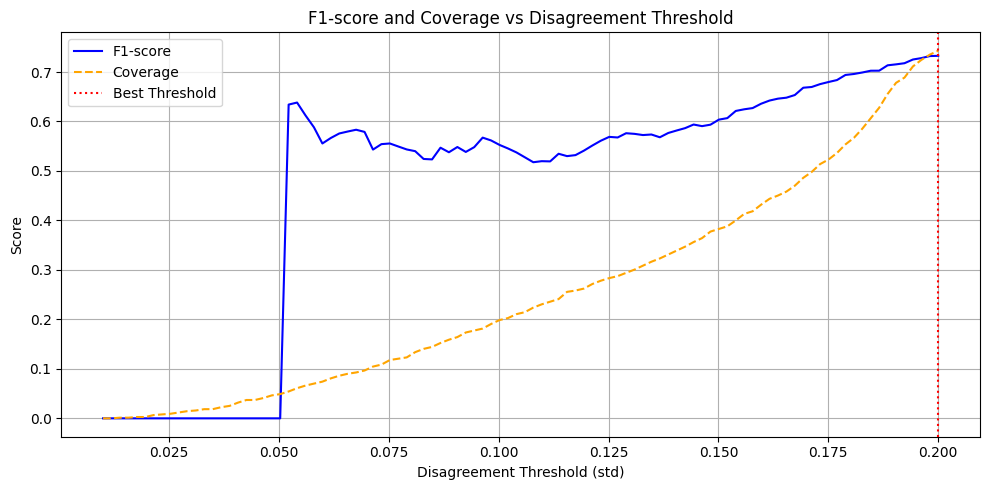

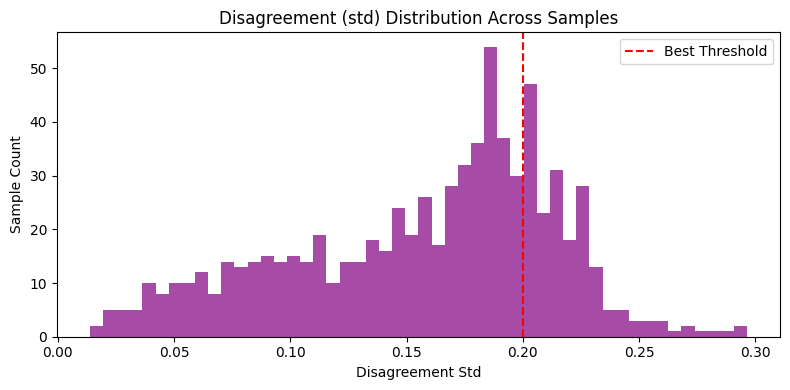

In [32]:
model_list = []
for model_package in models:
    model_list.append( model_package['model'].fit(X, y) )

X_val=Valid_set.copy()
y_val=Valid_result.copy()

best_threshold, best_f1, best_coverage = optimize_disagreement_threshold(
    models=model_list,
    X_val=X_val,
    y_val=y_val,
    min_coverage=0.05,  # at least 5% of data
    verbose=True,
    plot=True,
    debug_plot=True
)

## feature selection:

In [53]:
import pandas as pd
import numpy as np
from sklearn.feature_selection import VarianceThreshold, SelectKBest, f_classif, mutual_info_classif, chi2, RFE
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance
from statsmodels.stats.outliers_influence import variance_inflation_factor
from xgboost import XGBClassifier
from boruta import BorutaPy
import shap
from scipy.stats import wilcoxon

# ---------------------------
# Feature Selection Functions
# ---------------------------

def low_variance_filter(X, threshold=1e-4):
    selector = VarianceThreshold(threshold=threshold)
    selector.fit(X)
    return X.columns[selector.get_support()]

def mi_filter(X, y, threshold=1e-4):
    mi = mutual_info_classif(X, y)
    selected = X.columns[mi > threshold]
    return selected

def feature_importances(X, y, model):
    model.fit(X, y)
    return X.columns[model.feature_importances_ > 0]

def correlation_filter(X, threshold=0.95):
    corr_matrix = X.corr().abs()
    upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    to_drop = [column for column in upper.columns if any(upper[column] > threshold)]
    return X.drop(columns=to_drop).columns

def f_test_pvalue_filter(X, y, alpha=0.05):
    selector = SelectKBest(score_func=f_classif, k='all')
    selector.fit(X, y)
    return X.columns[selector.pvalues_ < alpha]

def boruta_filter(X, y, model):
    feat_selector = BorutaPy(model, n_estimators='auto', verbose=0, random_state=42)
    feat_selector.fit(X.values, y.values)
    return X.columns[feat_selector.support_]

def rfe_filter(X, y, model, n_features_to_select=10):
    selector = RFE(estimator=model, n_features_to_select=n_features_to_select, step=1)
    selector.fit(X, y)
    return X.columns[selector.support_]

def shap_filter(X, y, model, threshold=0.01):
    model.fit(X, y)
    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(X)

    mean_abs_shap = np.abs(shap_values).mean(axis=0).mean(axis=1)

    #print(mean_abs_shap, X.columns.to_numpy())
    selected_features = X.columns.to_numpy()[mean_abs_shap > threshold]
    return selected_features

def permutation_importance_filter(X, y, model, threshold=0.001):
    model.fit(X, y)
    result = permutation_importance(model, X, y, n_repeats=10, random_state=42)
    return X.columns[result.importances_mean > threshold]

def chi2_filter(X, y, threshold=0.05):
    X_nonneg = X.copy()
    X_nonneg[X_nonneg < 0] = 0
    chi_scores, p_values = chi2(X_nonneg, y)
    return X.columns[p_values < threshold]

def l1_filter(X, y, C=0.01):
    model = LogisticRegression(penalty='l1', solver='liblinear', C=C)
    model.fit(X, y)
    return X.columns[model.coef_[0] != 0]

def vif_filter(X, threshold=10):
    X = X.copy()
    while True:
        vif = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
        max_vif = max(vif)
        if max_vif > threshold:
            max_index = vif.index(max_vif)
            X.drop(columns=[X.columns[max_index]], inplace=True)
        else:
            break
    return X.columns


# ---------------------------
# Feature Scaling Functions:
# ---------------------------

from sklearn.preprocessing import MinMaxScaler, StandardScaler
import pandas as pd

def scale_minmax(data):
    """
    Scales features to range [0, 1] using MinMaxScaler.
    Useful for Chi2 and distance-based methods.
    """
    X= data.copy()
    rule_based_indicators = define_rule_based_indicators_list(X.copy())
    if rule_based_indicators != []:
        X = X.loc[:, ~X.columns.isin(rule_based_indicators)]
        
    scaler = MinMaxScaler()
    X_scaled = scaler.fit_transform(X)

    return pd.concat([pd.DataFrame(X_scaled, columns=X.columns, index=X.index), data.loc[:, rule_based_indicators]], axis='columns')

def scale_standard(data):
    """
    Scales features to zero mean and unit variance using StandardScaler.
    Useful for linear models (L1), permutation, and statistical tests like F-test.
    """
    X= data.copy()
    rule_based_indicators = define_rule_based_indicators_list(X.copy())
    if rule_based_indicators != []:
        X = X.loc[:, ~X.columns.isin(rule_based_indicators)]
        
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    
    return pd.concat([pd.DataFrame(X_scaled, columns=X.columns, index=X.index), data.loc[:, rule_based_indicators]], axis='columns')

def scale_none(X):
    return X.copy()


# ---------------------------
# Safe Wilcoxon Test
# ---------------------------

def safe_wilcoxon_test(before, after):
    diff = np.array(after) - np.array(before)
    if np.all(diff == 0):
        return None, 1.0
    return wilcoxon(before, after)


# ---------------------------
# Evaluation Pipeline
# ---------------------------

def evaluate_feature_filters(X, y, base_model):

    X_none = scale_none(X.copy())
    X_minmax = scale_minmax(X.copy())
    X_standard = scale_standard(X.copy())

    methods = {
        'Low Variance': low_variance_filter(X_none),
        'Mutual Info': mi_filter(X_none, y),
        'Correlation Filter': correlation_filter(X_none),
        'F-test': f_test_pvalue_filter(X_standard, y),
        'Permutation': permutation_importance_filter(X_standard, y, base_model),
        'Chi2': chi2_filter(X_minmax, y),
        'L1': l1_filter(X_standard, y),
        'VIF': vif_filter(X_none),
    }

    accepted = {}
    rejected = {}
    base_scores = evaluation_score_test(base_model=base_model, X_train_1=X.copy(), y_train_1=y.copy())
    
    for name, selected in methods.items():
        X_selected = X.loc[:, selected]
        selected_scores = evaluation_score_test(base_model=base_model, X_train_1=X_selected, y_train_1=y.copy())
        stat, p = safe_wilcoxon_test(base_scores, selected_scores)
        '''
        if p >= 0.05:
        '''
        if p < 0.05 or np.mean(selected_scores) > np.mean(base_scores):
            accepted[name] = {
                'features': list(selected),
                'mean_f1': np.mean(selected_scores),
                'p_value': p
            }
        else:
            rejected[name] = {
                'features': list(selected),
                'mean_f1': np.mean(selected_scores),
                'p_value': p
            }
    
    return accepted, rejected


# Combine all accepted feature sets using three strategies
import torch
from itertools import combinations

def create_collaboration_sets_combination_torch(accepted, feature_names):
    if not accepted:
        return {}

    method_names = list(accepted.keys())
    n_methods = len(method_names)
    n_features = len(feature_names)

    # Map feature names to index
    feature_idx_map = {name: i for i, name in enumerate(feature_names)}

    # Create binary tensor: shape (n_methods, n_features)
    method_tensor = torch.zeros((n_methods, n_features), dtype=torch.bool)

    for i, method in enumerate(method_names):
        selected_feats = accepted[method]['features']
        indices = [feature_idx_map[f] for f in selected_feats if f in feature_idx_map]
        method_tensor[i, indices] = 1  # mark selected features

    # Generate intersection sets from combinations (unordered)
    result_sets = {}
    for r in range(1, n_methods + 1):
        for combo in combinations(range(n_methods), r):
            combo_name = " ∩ ".join([method_names[i] for i in combo])
            intersected = method_tensor[combo[0]].clone()
            for idx in combo[1:]:
                intersected &= method_tensor[idx]
            if intersected.sum() > 0:
                selected_feature_names = [feature_names[i] for i in torch.where(intersected)[0]]
                result_sets[combo_name] = selected_feature_names

    return result_sets

### selecting:

In [54]:
X_train_1 = X.copy()
y_train_1 = y.copy()

accepted, rejected = evaluate_feature_filters(X=X_train_1, y=y_train_1, base_model=ensemble)

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/preprocessing/_label.py:97: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/preprocessing/_label.py:97: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/preprocessing/_label.py:97: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklea

In [55]:
print(f"accepted set:", accepted.keys())
print(f"rejected set:", rejected.keys())

accepted set: dict_keys(['Mutual Info', 'Correlation Filter', 'Permutation'])
rejected set: dict_keys(['Low Variance', 'F-test', 'Chi2', 'L1', 'VIF'])


In [56]:
# Create collaboration sets
combined_sets = create_collaboration_sets_combination_torch(accepted={**accepted, **rejected}, feature_names=X_train_1.columns.tolist())
for key, item in combined_sets.items():
    print(f"{key}: {len(item)}")
'''
# Create collaboration sets
if combined_sets == {}:
    combined_sets = create_collaboration_sets_combination_torch(accepted=rejected, feature_names=X_train_1.columns.tolist())
    for key, item in combined_sets.items():
        print(f"{key}: {len(item)}")
'''

Mutual Info: 37
Correlation Filter: 57
Permutation: 88
Low Variance: 91
F-test: 20
Chi2: 2
L1: 4
VIF: 30
Mutual Info ∩ Correlation Filter: 29
Mutual Info ∩ Permutation: 36
Mutual Info ∩ Low Variance: 37
Mutual Info ∩ F-test: 15
Mutual Info ∩ Chi2: 1
Mutual Info ∩ L1: 3
Mutual Info ∩ VIF: 14
Correlation Filter ∩ Permutation: 54
Correlation Filter ∩ Low Variance: 57
Correlation Filter ∩ F-test: 17
Correlation Filter ∩ Chi2: 2
Correlation Filter ∩ L1: 4
Correlation Filter ∩ VIF: 28
Permutation ∩ Low Variance: 88
Permutation ∩ F-test: 18
Permutation ∩ L1: 4
Permutation ∩ VIF: 27
Low Variance ∩ F-test: 20
Low Variance ∩ Chi2: 2
Low Variance ∩ L1: 4
Low Variance ∩ VIF: 30
F-test ∩ Chi2: 2
F-test ∩ L1: 4
F-test ∩ VIF: 10
Chi2 ∩ VIF: 2
L1 ∩ VIF: 2
Mutual Info ∩ Correlation Filter ∩ Permutation: 28
Mutual Info ∩ Correlation Filter ∩ Low Variance: 29
Mutual Info ∩ Correlation Filter ∩ F-test: 12
Mutual Info ∩ Correlation Filter ∩ Chi2: 1
Mutual Info ∩ Correlation Filter ∩ L1: 3
Mutual Info ∩ Cor

'\n# Create collaboration sets\nif combined_sets == {}:\n    combined_sets = create_collaboration_sets_combination_torch(accepted=rejected, feature_names=X_train_1.columns.tolist())\n    for key, item in combined_sets.items():\n        print(f"{key}: {len(item)}")\n'

In [57]:
feature_set = {}
for idx, features in combined_sets.items():
    value_to_find = features
    if value_to_find not in feature_set.values() or feature_set == {}:
        matching_keys = [k for k, v in combined_sets.items() if v == value_to_find]
        feature_set[matching_keys[0]] = features
        
len(feature_set.keys()), len(combined_sets.keys())

(37, 159)

### Selected Feature Set:

In [58]:
X_train_1 = X.copy()
y_train_1 = y.copy()

base_scores = evaluation_score_test(base_model=ensemble, X_train_1=X_train_1, y_train_1=y_train_1)
selected = {
    'orginal': {
        'feature': X_train_1.columns.tolist(),
        'score': base_scores
    }
}
for name, features in feature_set.items():
    X_subset = X_train_1.loc[:, features]
    scores_subset = evaluation_score_test(base_model=ensemble, X_train_1=X_subset, y_train_1=y_train_1.copy())
    if np.mean(scores_subset) > np.mean(base_scores):
        stat, p = safe_wilcoxon_test(base_scores, scores_subset)

        print(f"\n{name}: p={p:.4f}, mean_f1={scores_subset.mean():.4f}, features={len(features)}")
        
        selected[name] = {
            'feature': features,
            'score': scores_subset
        }

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/preprocessing/_label.py:97: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/preprocessing/_label.py:97: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/preprocessing/_label.py:132: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, dtype=self.classes_.dtype, warn=True)
/Library/Frameworks/Python.framework/Versions/3.12/lib/py


Mutual Info: p=1.0000, mean_f1=0.7637, features=37


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:349: ConvergenceWarning: The ma


Correlation Filter: p=1.0000, mean_f1=0.7649, features=57


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/preprocessing/_label.py:97: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/preprocessing/_label.py:97: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/preprocessing/_label.py:132: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, dtype=self.classes_.dtype, warn=True)
/Library/Frameworks/Python.framework/Versions/3.12/lib/py

...

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/preprocessing/_label.py:97: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/preprocessing/_label.py:97: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/preprocessing/_label.py:132: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, dtype=self.classes_.dtype, warn=True)
/Library/Frameworks/Python.framework/Versions/3.12/lib/py


Mutual Info ∩ Correlation Filter: p=1.0000, mean_f1=0.7610, features=29


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/preprocessing/_label.py:97: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/preprocessing/_label.py:132: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, dtype=self.classes_.dtype, warn=True)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/preprocessing/_label.py:97: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/Library/Frameworks/Python.framework/Versions/3.12/lib/py


Correlation Filter ∩ Permutation: p=1.0000, mean_f1=0.7605, features=54


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/preprocessing/_label.py:97: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/preprocessing/_label.py:132: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, dtype=self.classes_.dtype, warn=True)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/preprocessing/_label.py:97: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/Library/Frameworks/Python.framework/Versions/3.12/lib/py

In [59]:
scores=[]
for key in selected.keys():
    scores.append(selected[key]['score'])
    
selected_feature_set = selected[list(selected.keys())[np.argmax(scores)]]['feature']
print(list(selected.keys())[np.argmax(scores)])
print(selected_feature_set)

Permutation
['open', 'high', 'low', 'close', 'volume', 'volume_adi', 'volume_obv', 'volume_cmf', 'volume_fi', 'volume_em', 'volume_sma_em', 'volume_vpt', 'volume_vwap', 'volume_mfi', 'volume_nvi', 'volatility_bbm', 'volatility_bbh', 'volatility_bbl', 'volatility_bbw', 'volatility_bbp', 'volatility_bbhi', 'volatility_bbli', 'volatility_kcc', 'volatility_kch', 'volatility_kcl', 'volatility_kcw', 'volatility_kcp', 'volatility_kchi', 'volatility_kcli', 'volatility_dcl', 'volatility_dch', 'volatility_dcm', 'volatility_dcw', 'volatility_dcp', 'volatility_atr', 'volatility_ui', 'trend_macd', 'trend_macd_signal', 'trend_macd_diff', 'trend_sma_fast', 'trend_sma_slow', 'trend_ema_fast', 'trend_ema_slow', 'trend_vortex_ind_pos', 'trend_vortex_ind_neg', 'trend_vortex_ind_diff', 'trend_mass_index', 'trend_dpo', 'trend_kst', 'trend_kst_sig', 'trend_kst_diff', 'trend_ichimoku_conv', 'trend_ichimoku_base', 'trend_ichimoku_a', 'trend_ichimoku_b', 'trend_stc', 'trend_adx', 'trend_adx_pos', 'trend_adx_ne

### Before & After test:

In [60]:
X_subset = X_train_1.loc[:, selected_feature_set]

scores_subset = evaluation_score_test_2(base_model=ensemble, X_train_1=X_subset, y_train_1=y_train_1)
base_scores = evaluation_score_test_2(base_model=ensemble, X_train_1=X_train_1, y_train_1=y_train_1)

In [61]:
print(f"Base Score: {np.mean(base_scores)}")
print( f"Selected Feature Score: {np.mean(scores_subset)}" )

Base Score: 0.7729583141658216
Selected Feature Score: 0.7710340881274848


## threshold tuning

In [62]:
from sklearn.metrics import precision_recall_curve
import numpy as np

X_train_1= X.loc[:, selected_feature_set].copy()
y_train_1= y.copy()

all_proba = []
all_true = []
thresholds = []
for train_idx, test_idx in purged_kfold_split(X_train_1):
    X_train, X_test = X_train_1.iloc[train_idx], X_train_1.iloc[test_idx]
    y_train, y_test = y_train_1.iloc[train_idx], y_train_1.iloc[test_idx]
    
    ensemble.fit(X_train, y_train)
    y_proba = ensemble.predict_proba(X_test)[:, 1]  # Probabilities
    
    precision, recall, thr = precision_recall_curve(y_test, y_proba)
    f1 = 2 * precision * recall / (precision + recall + 1e-6)
    thresholds.append(thr[f1.argmax()])
    
    all_proba.extend(y_proba)
    all_true.extend(y_test.values.T[0])

best_threshold = np.mean(thresholds)
print(f"Best threshold: {best_threshold:.2f}")

Best threshold: 0.49


### Pre-Test:

In [63]:
from matplotlib import pyplot as plt

X_train_1 = Ensemble_Feature_Selection(X.copy(), selected_feature_set)
y_train_1 = y.copy()
X_test_1 = Valid_set.loc[:, X_train_1.columns].copy()
y_test_1 = Valid_result.copy()

def testing(test_set, test_result):
    calibrated_model = CalibratedClassifierCV(ensemble, method='sigmoid', cv=5)
    calibrated_model.fit(X=X_train_1, y=y_train_1)
    y_proba_1 = calibrated_model.predict_proba(test_set)[:, 1]

    precision, recall, thresholds = precision_recall_curve(test_result, y_proba_1)
    f1 = 2 * precision * recall / (precision + recall + 1e-6)
    best_threshold = thresholds[np.argmax(f1)]

    print(f"Best threshold: {best_threshold:.2f}, F1 score: {max(f1):.4f}")

    plt.plot(thresholds, f1[:-1], label='F1')
    plt.plot(thresholds, precision[:-1], label='Precision')
    plt.plot(thresholds, recall[:-1], label='Recall')
    plt.xlabel('Threshold')
    plt.legend()
    plt.title('Precision, Recall, F1 vs Threshold')
    plt.grid()
    plt.show()

    plt.hist(y_proba_1[np.array(test_result).T[0]==0], bins=50, alpha=0.5, label='Class 0')
    plt.hist(y_proba_1[np.array(test_result).T[0]==1], bins=50, alpha=0.5, label='Class 1')
    plt.axvline(x= best_threshold, linestyle="--", linewidth=3, color="black")
    plt.legend()
    plt.title(f"Probability Distribution by True Class")
    plt.show()

Best threshold: 0.46, F1 score: 1.0000


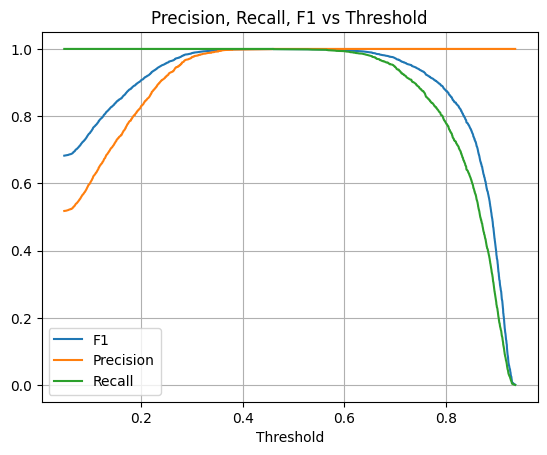

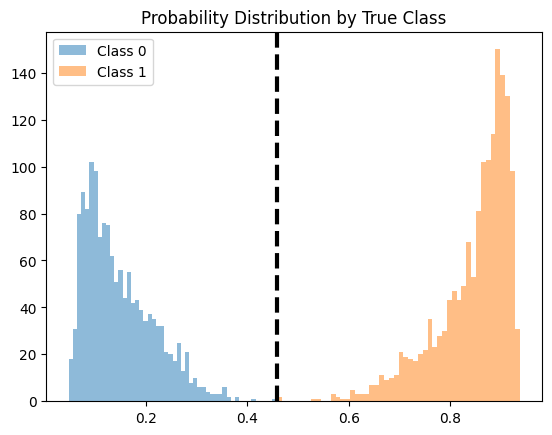

In [64]:
testing( test_result=y_train_1, test_set=X_train_1 )

Best threshold: 0.42, F1 score: 0.7871


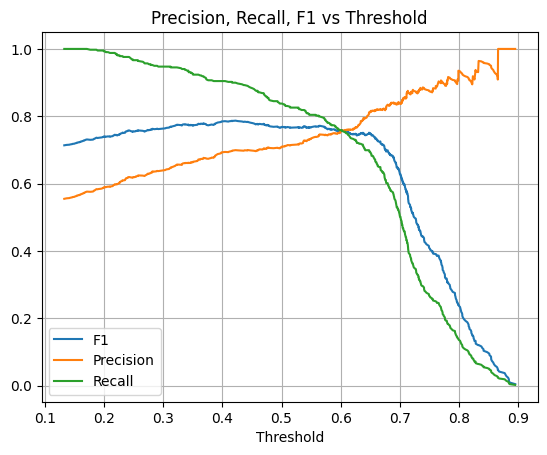

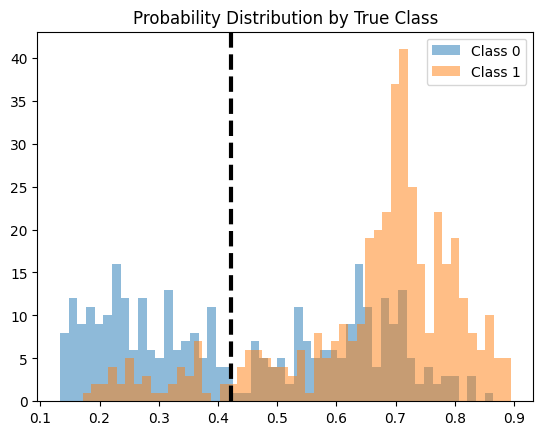

In [65]:
testing(test_result=y_test_1, test_set=X_test_1)

### Before & After test:

In [ ]:
base_scores = dataframe_from_models_package(ensemble, selected_feature_set)
scores_subset = dataframe_from_models_package(ensemble, selected_feature_set, best_threshold)

(array([0, 1]), array([312, 291]))
(array([0, 1]), array([229, 374]))
(array([0, 1]), array([315, 288]))
(array([0, 1]), array([207, 396]))
(array([0, 1]), array([111, 492]))
(array([1]), array([755]))
(array([0, 1]), array([300, 303]))
(array([0, 1]), array([226, 377]))
(array([0, 1]), array([313, 290]))
(array([0, 1]), array([201, 402]))
(array([0, 1]), array([101, 502]))
(array([0, 1]), array([254, 501]))
(array([0, 1]), array([416, 187]))
(array([0, 1]), array([290, 313]))
(array([0, 1]), array([376, 227]))
(array([0, 1]), array([264, 339]))
(array([0, 1]), array([184, 419]))
(array([0, 1]), array([334, 421]))


In [ ]:
print(f"Base Score: {np.mean(base_scores)}")
print(f"Threshold Score: {np.mean(scores_subset)}")

Base Score: 0.7424165329904886
Threshold Score 1: 0.7504924534081945
Threshold Score: 0.7699007474822787
